In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import os
import time

import onnx
import onnxruntime as ort
from onnxruntime.quantization import quantize_static, CalibrationDataReader, QuantType

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Koristim: {device}")

Koristim: cpu


In [18]:
# Definisanje CNN modela sa Batch Normalizacijom

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2)
        
    
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   
        x = self.pool(F.relu(self.bn3(self.conv3(x))))   
        x = x.view(-1, 128 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
print("Model kreiran")

Model kreiran


In [3]:
# Učitavanje CIFAR-10 dataseta

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train dataset: {len(train_dataset)} slika")
print(f"Test dataset: {len(test_dataset)} slika")

Train dataset: 50000 slika
Test dataset: 10000 slika


In [4]:
# Treniranje modela

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

print("Treniranje...")
num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    scheduler.step()
    train_acc = 100 * correct / total
    print(f"Epoha [{epoch+1}/{num_epochs}], Gubitak: {running_loss/len(train_loader):.4f}, Tačnost: {train_acc:.2f}%")

print("Zavrseno!")

Treniranje...
Epoha [1/15], Gubitak: 1.2711, Tačnost: 53.76%
Epoha [2/15], Gubitak: 0.9213, Tačnost: 67.42%
Epoha [3/15], Gubitak: 0.7869, Tačnost: 72.16%
Epoha [4/15], Gubitak: 0.6933, Tačnost: 75.72%
Epoha [5/15], Gubitak: 0.6221, Tačnost: 78.28%
Epoha [6/15], Gubitak: 0.4561, Tačnost: 84.10%
Epoha [7/15], Gubitak: 0.4211, Tačnost: 85.34%
Epoha [8/15], Gubitak: 0.3965, Tačnost: 86.15%
Epoha [9/15], Gubitak: 0.3827, Tačnost: 86.73%
Epoha [10/15], Gubitak: 0.3660, Tačnost: 87.08%
Epoha [11/15], Gubitak: 0.3405, Tačnost: 88.20%
Epoha [12/15], Gubitak: 0.3361, Tačnost: 88.38%
Epoha [13/15], Gubitak: 0.3333, Tačnost: 88.42%
Epoha [14/15], Gubitak: 0.3328, Tačnost: 88.28%
Epoha [15/15], Gubitak: 0.3280, Tačnost: 88.70%
Zavrseno!


In [5]:
# Evaluacija FP32 modela

def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

accuracy_fp32 = evaluate_model(model, test_loader)
print(f"Tačnost FP32 modela na test skupu: {accuracy_fp32:.2f}%")

Tačnost FP32 modela na test skupu: 81.28%


In [6]:
# Konverzija modela u ONNX format (fiksne dimenzije)

import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger('torch.onnx').setLevel(logging.ERROR)

model_cpu = model.to('cpu')
model_cpu.eval()

dummy_input = torch.randn(1, 3, 32, 32)
onnx_file_path = "simple_cnn_fixed.onnx"

torch.onnx.export(
    model_cpu,
    dummy_input,
    onnx_file_path,
    export_params=True,
    opset_version=11,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    verbose=False
)

print("Konverzija modela u ONNX format je izvrsena.")

The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "C:\Users\Korisnik\AppData\Local\Programs\Python\Python312\Lib\site-packages\onnxscript\version_converter\__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Korisnik\AppData\Local\Programs\Python\Python312\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "C:\Users\Korisnik\AppData\Local\Programs\Python\Python312\Lib\site-packages\onnxscript\version_converter\__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^

Konverzija modela u ONNX format je izvrsena.


In [7]:
# Provera ispravnosti izvoza

onnx_model = onnx.load(onnx_file_path)

try:
    onnx.checker.check_model(onnx_model)
    print("ONNX model je validan.")
except Exception as e:
    print(f"Greska: {e}")

def compare_outputs(model, onnx_file_path):
    ort_session = ort.InferenceSession(onnx_file_path)
    
    images, labels = next(iter(test_loader))
    first_image = images[0:1].numpy()
    
    model.eval()
    with torch.no_grad():
        pytorch_output = model(images[0:1]).numpy()
    
    ort_inputs = {ort_session.get_inputs()[0].name: first_image}
    ort_outputs = ort_session.run(None, ort_inputs)
    onnx_output = ort_outputs[0]
    
    diff = np.max(np.abs(pytorch_output - onnx_output))
    print(f"Maksimalna razlika: {diff:.6f}")
    
    if diff < 1e-5:
        print("Razlika je zanemarljiva (< 1e-5). Konverzija je uspesna.")
    else:
        print("Razlika je veca od ocekivane.")
    
    return diff

compare_outputs(model_cpu, onnx_file_path)

ONNX model je validan.
Maksimalna razlika: 0.000002
Razlika je zanemarljiva (< 1e-5). Konverzija je uspesna.


1.9073486e-06

In [8]:
# Definisanje CalibrationDataReader-a za staticku kvantizaciju

class SimpleDataReader(CalibrationDataReader):
    def __init__(self, test_loader):
        self.test_loader = test_loader
        self.iter = iter(test_loader)
    
    def get_next(self):
        try:
            images, _ = next(self.iter)
            first_image = images[0:1].numpy()
            return {'input': first_image}
        except StopIteration:
            self.iter = iter(self.test_loader)
            return None

In [19]:
# Popravka modela pre kvantizacije
from onnxruntime.quantization.shape_inference import quant_pre_process


input_model_path = "simple_cnn_fixed.onnx"

prepared_model_path = "simple_cnn_prepared.onnx"

quant_pre_process(input_model_path, prepared_model_path, skip_symbolic_shape=True)
print(f"Model je pripremljen za kvantizaciju: {prepared_model_path}")

onnx_file_path = prepared_model_path

Model je pripremljen za kvantizaciju: simple_cnn_prepared.onnx


In [10]:
# Staticka 8-bit kvantizacija
print("8-bit staticka kvantizacija...")

calib_reader = SimpleDataReader(test_loader)
quantized_model_path_8bit = "simple_cnn_quantized_8bit.onnx"

try:
    quantize_static(
        model_input=prepared_model_path,  
        model_output=quantized_model_path_8bit,
        calibration_data_reader=calib_reader,
        weight_type=QuantType.QInt8,
    )
    print(f"kvantizacija je zavrsena. Model: {quantized_model_path_8bit}")
    kvantizacija_uspesna = True
except Exception as e:
    print(f"Greska pri kvantizaciji: {e}")
    kvantizacija_uspesna = False

8-bit staticka kvantizacija...
kvantizacija je zavrsena. Model: simple_cnn_quantized_8bit.onnx


In [20]:
# FP16 kvantizacija kroz onnxconverter-common

import onnx
from onnxconverter_common import float16

print("FP16 kvantizacija...")

quantized_model_path_fp16 = "simple_cnn_quantized_fp16.onnx"

model_fp32 = onnx.load(onnx_file_path)

model_fp16 = float16.convert_float_to_float16(model_fp32)

onnx.save(model_fp16, quantized_model_path_fp16)

print(f"FP16 kvantizacija završena. Model: {quantized_model_path_fp16}")

fp16_size = os.path.getsize(quantized_model_path_fp16) / (1024 * 1024)
print(f"Veličina FP16 modela: {fp16_size:.2f} MB")

FP16 kvantizacija...
FP16 kvantizacija završena. Model: simple_cnn_quantized_fp16.onnx
Veličina FP16 modela: 1.20 MB


In [21]:
# Evaluacija tacnosti

def evaluate_onnx_model(onnx_file_path, test_loader, is_fp16=False):

    ort_session = ort.InferenceSession(onnx_file_path)
    correct = 0
    total = 0
    
    for images, labels in test_loader:
        for i in range(images.shape[0]):
            single_image = images[i:i+1].numpy()
            
            if is_fp16:
                single_image = single_image.astype(np.float16)
            
            ort_inputs = {ort_session.get_inputs()[0].name: single_image}
            ort_outputs = ort_session.run(None, ort_inputs)
            predicted_label = np.argmax(ort_outputs[0], axis=1)[0]
            
            total += 1
            correct += (predicted_label == labels[i].item())
    
    return 100 * correct / total

print("Evaluacija modela...")

acc_fp32 = evaluate_onnx_model(onnx_file_path, test_loader, is_fp16=False)
acc_fp16 = evaluate_onnx_model(quantized_model_path_fp16, test_loader, is_fp16=True)
acc_8bit = evaluate_onnx_model(quantized_model_path_8bit, test_loader, is_fp16=False)

print(f"FP32 model tacnost: {acc_fp32:.2f}%")
print(f"FP16 model tacnost: {acc_fp16:.2f}%")
print(f"INT8 model tacnost:  {acc_8bit:.2f}%")

Evaluacija modela...
FP32 model tacnost: 81.28%
FP16 model tacnost: 81.30%
INT8 model tacnost:  81.25%


In [22]:
# Merenje brzine zakljucivanja

def measure_inference_speed(onnx_file_path, num_runs=100, is_fp16=False):
    
    ort_session = ort.InferenceSession(onnx_file_path)
    

    if is_fp16:
        dummy_input = np.random.randn(1, 3, 32, 32).astype(np.float16)
    else:
        dummy_input = np.random.randn(1, 3, 32, 32).astype(np.float32)
    
    for _ in range(10):
        ort_session.run(None, {ort_session.get_inputs()[0].name: dummy_input})
    
    start_time = time.time()
    for _ in range(num_runs):
        ort_session.run(None, {ort_session.get_inputs()[0].name: dummy_input})
    end_time = time.time()
    
    avg_time = (end_time - start_time) / num_runs * 1000
    return avg_time

print("Merenje brzine zakljucivanja...")
speed_fp32 = measure_inference_speed(onnx_file_path, 100, is_fp16=False)
speed_fp16 = measure_inference_speed(quantized_model_path_fp16, 100, is_fp16=True)
speed_8bit = measure_inference_speed(quantized_model_path_8bit, 100, is_fp16=False)

print(f"FP32 model: {speed_fp32:.2f} ms po inferenciji")
print(f"FP16 model: {speed_fp16:.2f} ms po inferenciji")
print(f"INT8 model: {speed_8bit:.2f} ms po inferenciji")

Merenje brzine zakljucivanja...
FP32 model: 0.66 ms po inferenciji
FP16 model: 0.89 ms po inferenciji
INT8 model: 0.40 ms po inferenciji


In [25]:
# Tabela poredjenja

# Provera da li su sve varijable definisane
try:
    fp32_size
except NameError:
    fp32_size = os.path.getsize(onnx_file_path) / (1024 * 1024)
    print(f"fp32_size definisan: {fp32_size:.2f} MB")

try:
    fp16_size
except NameError:
    fp16_size = os.path.getsize(quantized_model_path_fp16) / (1024 * 1024)
    print(f"fp16_size definisan: {fp16_size:.2f} MB")

try:
    quant8_size
except NameError:
    quant8_size = os.path.getsize(quantized_model_path_8bit) / (1024 * 1024)
    print(f"quant8_size definisan: {quant8_size:.4f} MB")

try:
    speed_fp32
except NameError:
    speed_fp32 = measure_inference_speed(onnx_file_path, 100)
    print(f"speed_fp32 definisan: {speed_fp32:.2f} ms")

try:
    speed_fp16
except NameError:
    speed_fp16 = measure_inference_speed(quantized_model_path_fp16, 100)
    print(f"speed_fp16 definisan: {speed_fp16:.2f} ms")

try:
    speed_8bit
except NameError:
    speed_8bit = measure_inference_speed(quantized_model_path_8bit, 100)
    print(f"speed_8bit definisan: {speed_8bit:.2f} ms")

try:
    acc_fp32
except NameError:
    acc_fp32 = evaluate_onnx_model(onnx_file_path, test_loader)
    print(f"acc_fp32 definisan: {acc_fp32:.2f}%")

try:
    acc_fp16
except NameError:
    acc_fp16 = evaluate_onnx_model(quantized_model_path_fp16, test_loader)
    print(f"acc_fp16 definisan: {acc_fp16:.2f}%")

try:
    acc_8bit
except NameError:
    acc_8bit = evaluate_onnx_model(quantized_model_path_8bit, test_loader)
    print(f"acc_8bit definisan: {acc_8bit:.2f}%")


print("TABELA POREĐENJA PERFORMANSI")

print(f"{'Model':<12} {'Tacnost':<14} {'Velicina (MB)':<15} {'Brzina (ms)'}")
print("-"*55)
print(f"{'FP32':<12} {acc_fp32:<13.2f}% {fp32_size:<14.2f} {speed_fp32:<11.2f}")
print(f"{'FP16':<12} {acc_fp16:<13.2f}% {fp16_size:<14.2f} {speed_fp16:<11.2f}")
print(f"{'INT8':<12} {acc_8bit:<13.2f}% {quant8_size:<14.2f} {speed_8bit:<11.2f}")

print("ZAKLJUČAK:")

print(f"FP16 model je {fp32_size/fp16_size:.1f}x manji od FP32 modela")
print(f"INT8 model je {fp32_size/quant8_size:.1f}x manji od FP32 modela")
print(f"FP16 model je {speed_fp32/speed_fp16:.1f}x brži od FP32 modela")
print(f"INT8 model je {speed_fp32/speed_8bit:.1f}x brži od FP32 modela")
print(f"Gubitak tačnosti FP16 modela: {acc_fp32 - acc_fp16:.2f}%")
print(f"Gubitak tačnosti INT8 modela: {acc_fp32 - acc_8bit:.2f}%")

TABELA POREĐENJA PERFORMANSI
Model        Tacnost        Velicina (MB)   Brzina (ms)
-------------------------------------------------------
FP32         81.28        % 2.38           0.66       
FP16         81.30        % 1.20           0.89       
INT8         81.25        % 0.61           0.40       
ZAKLJUČAK:
FP16 model je 2.0x manji od FP32 modela
INT8 model je 3.9x manji od FP32 modela
FP16 model je 0.7x brži od FP32 modela
INT8 model je 1.6x brži od FP32 modela
Gubitak tačnosti FP16 modela: -0.02%
Gubitak tačnosti INT8 modela: 0.03%


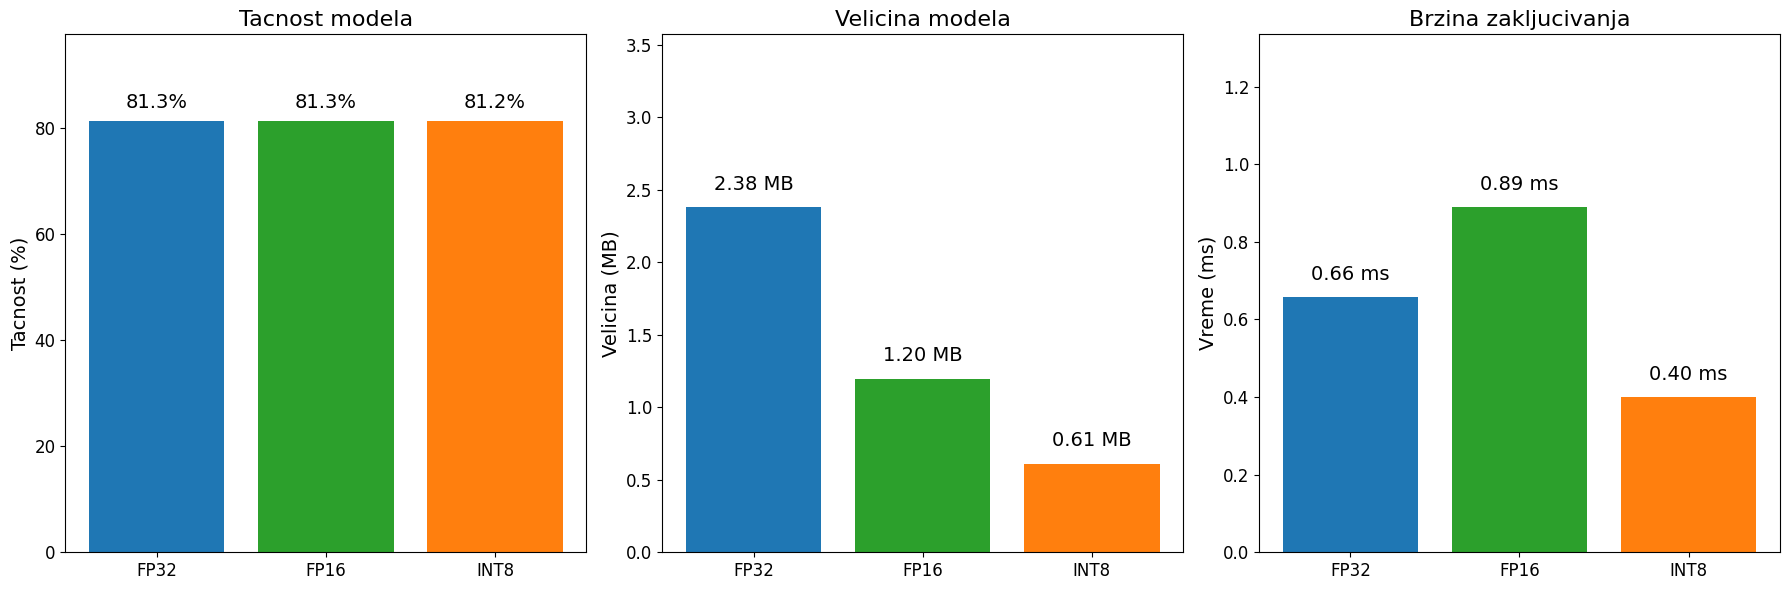

In [26]:
# Grafik prikaza rezultata

models = ['FP32', 'FP16', 'INT8']
accuracies = [acc_fp32, acc_fp16, acc_8bit]
sizes = [fp32_size, fp16_size, quant8_size]
speeds = [speed_fp32, speed_fp16, speed_8bit]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Grafik tacnosti
max_acc = max(accuracies) if max(accuracies) > 0 else 1
axes[0].bar(models, accuracies, color=['#1f77b4', '#2ca02c', '#ff7f0e'])
axes[0].set_title('Tacnost modela', fontsize=16)
axes[0].set_ylabel('Tacnost (%)', fontsize=14)
axes[0].set_ylim(0, max_acc * 1.2)
axes[0].tick_params(axis='both', labelsize=12)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + (max_acc * 0.03), f'{v:.1f}%', ha='center', fontsize=14)

# Grafik velicine
max_size = max(sizes) if max(sizes) > 0 else 1
axes[1].bar(models, sizes, color=['#1f77b4', '#2ca02c', '#ff7f0e'])
axes[1].set_title('Velicina modela', fontsize=16)
axes[1].set_ylabel('Velicina (MB)', fontsize=14)
axes[1].set_ylim(0, max_size * 1.5)
axes[1].tick_params(axis='both', labelsize=12)
for i, v in enumerate(sizes):
    axes[1].text(i, v + (max_size * 0.05), f'{v:.2f} MB', ha='center', fontsize=14)

# Grafik brzine
max_speed = max(speeds) if max(speeds) > 0 else 1
axes[2].bar(models, speeds, color=['#1f77b4', '#2ca02c', '#ff7f0e'])
axes[2].set_title('Brzina zakljucivanja', fontsize=16)
axes[2].set_ylabel('Vreme (ms)', fontsize=14)
axes[2].set_ylim(0, max_speed * 1.5)
axes[2].tick_params(axis='both', labelsize=12)
for i, v in enumerate(speeds):
    axes[2].text(i, v + (max_speed * 0.05), f'{v:.2f} ms', ha='center', fontsize=14)

plt.tight_layout()
plt.show()